In [ ]:
from preamble import *
%matplotlib inline

## Algorithm Chains and Pipelines

In [5]:
#
# без пайплайна
#
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

scaler = MinMaxScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

svm = SVC()
svm.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
print(svm.score(X_test_scaled, y_test))

0.972027972027972


### Building Pipelines

In [10]:
#
# простой пайплайн
#
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("svm", SVC())
    ]
)
pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))

0.972027972027972


### Using Pipelines in Grid-searches

In [9]:
#
# пайплайн внутри GridSearch
#
from sklearn.model_selection import GridSearchCV
param_grid = {
    'svm__C':     [0.001, 0.01, 0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(pipe,
                    param_grid=param_grid,
                    cv=5
)
grid.fit(X_train, y_train)
print(grid.best_score_)
print(grid.score(X_test, y_test))
print(grid.best_params_)

0.9812311901504789
0.972027972027972
{'svm__C': 1, 'svm__gamma': 1}


### Convenient Pipeline creation with ``make_pipeline``

In [18]:
#
# Короткий способ создания пайплайна
#
from sklearn.pipeline import make_pipeline

pipe_short = make_pipeline(MinMaxScaler(),
                           SVC(C=100)
)
print(pipe_short.steps)

pipe = make_pipeline(StandardScaler(),
                     PCA(n_components=2),
                     StandardScaler()
)
print(pipe.steps)
print('\n', pipe.named_steps)

[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]

 {'standardscaler-1': StandardScaler(), 'pca': PCA(n_components=2), 'standardscaler-2': StandardScaler()}



### Accessing step attributes

In [15]:
#
# доступ к внутренностям пайплайна
#
pipe.fit(cancer.data)
pipe.named_steps["pca"].components_.shape

(2, 30)

### Accessing Attributes in a Pipeline inside GridSearchCV

In [27]:
#
# доступ к внутренностям пайплайна внутри GridSearch
#
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=4)

pipe = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=1000)
)

param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(pipe,
                    param_grid,
                    cv=5
)
grid.fit(X_train, y_train)
print(grid.best_estimator_)
print(grid.best_estimator_.named_steps["logisticregression"])
print(grid.best_estimator_.named_steps["logisticregression"].coef_)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1, max_iter=1000))])
LogisticRegression(C=1, max_iter=1000)
[[-0.4475566  -0.34609376 -0.41703843 -0.52889408 -0.15784407  0.60271339
  -0.71771325 -0.78367478  0.04847448  0.27478533 -1.29504052  0.05314385
  -0.69103766 -0.91925087 -0.14791795  0.46138699 -0.1264859  -0.10289486
   0.42812714  0.71492797 -1.08532414 -1.09273614 -0.85133685 -1.04104568
  -0.72839683  0.07656216 -0.83641023 -0.64928603 -0.6491432  -0.42968125]]


### Grid-searching preprocessing steps and model parameters

In [35]:
from sklearn.datasets import fetch_california_housing

# Загружаем California Housing
california = fetch_california_housing()
import pandas as pd
pd.DataFrame(california.data, columns=california.feature_names).head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

X_train, X_test, y_train, y_test = train_test_split(
    california.data, california.target, random_state=0
)
pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(),
    Ridge()
)
param_grid = {
    'polynomialfeatures__degree': [1, 2, 3],
    'ridge__alpha':               [0.001, 0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(pipe,
                    param_grid=param_grid,
                    cv=5,
                    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

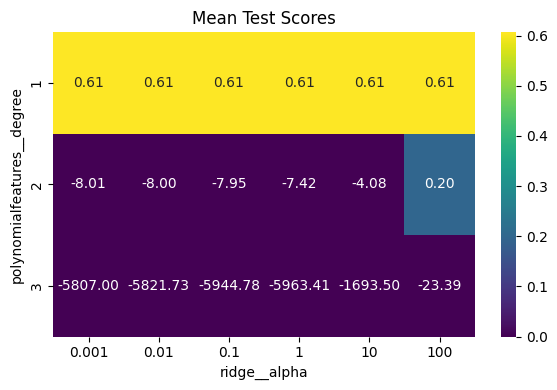

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Получаем данные
scores = grid.cv_results_['mean_test_score'].reshape(3, -1)

# Создаем тепловую карту
plt.figure(figsize=(6, 4))
sns.heatmap(scores,
            xticklabels=param_grid['ridge__alpha'],
            yticklabels=param_grid['polynomialfeatures__degree'],
            annot=True,           # показывать значения в ячейках
            fmt='.2f',            # формат чисел
            cmap='viridis',       # цветовая схема
            vmin=0,               # минимальное значение для цветовой шкалы
            vmax=None,            # максимальное значение автоматически
            cbar=True)
plt.xlabel('ridge__alpha')
plt.ylabel('polynomialfeatures__degree')
plt.title('Mean Test Scores')
plt.tight_layout()
plt.show()

In [39]:
grid.best_params_

{'polynomialfeatures__degree': 1, 'ridge__alpha': 10}

In [40]:
grid.score(X_test, y_test)

0.5910937377294635

In [45]:
#
# перебор целых моделей
#
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

pipe = Pipeline(
    [
        ('preprocessing', StandardScaler()),
        ('classifier', SVC())
    ]
)

from sklearn.ensemble import RandomForestClassifier
param_grid = [
    # === ВАРИАНТ 1: SVC с разными предобработками ===
    {
        'classifier': [SVC()],              # ← модель SVC
        'preprocessing': [StandardScaler(), None],  # ← с масштабированием или без
        'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
    },

    # === ВАРИАНТ 2: Random Forest без предобработки ===
    {
        'classifier': [RandomForestClassifier(n_estimators=100)],  # ← модель RF
        'preprocessing': [None],          # ← только без масштабирования
        'classifier__max_features': [1, 2, 3]  # ← параметры RF
    }
]
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test, y_test))

{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}
0.9858823529411765
0.9790209790209791


Best params:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

Best cross-validation score: 0.99
Test-set score: 0.98


#### Avoiding Redundant Computation

In [ ]:
#
# кэширование
#
pipe = Pipeline(
    [
        ('preprocessing', StandardScaler()),
        ('classifier', SVC())
    ],
    memory="cache_folder"
)

### Summary and Outlook